**Import & Load Dataset**

In [ ]:
# Install library to read ARFF files
!pip install scipy --quiet

from scipy.io import arff
import pandas as pd
import io

# Upload the file
from google.colab import files
uploaded = files.upload()

# Load ARFF file
filename = list(uploaded.keys())[0]
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

# Convert byte strings to numbers
df = df.applymap(lambda x: int(x) if isinstance(x, bytes) else x)
df = df.astype(int)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Saving Training Dataset.arff to Training Dataset (1).arff
Dataset loaded successfully!
Shape: (11055, 31)

Columns: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

First 3 rows:


/tmp/ipykernel_18062/571719775.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, bytes) else x)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1


**EDA**

Class distribution, null check, heatmap

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor            

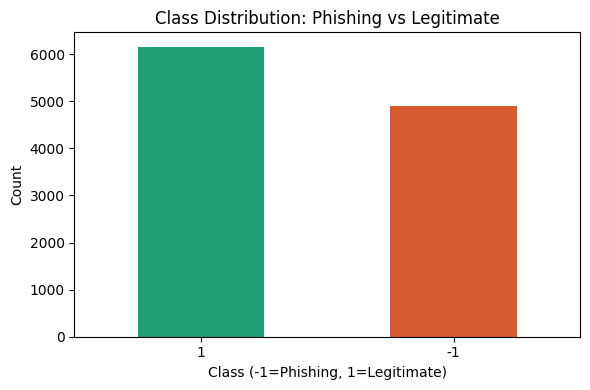

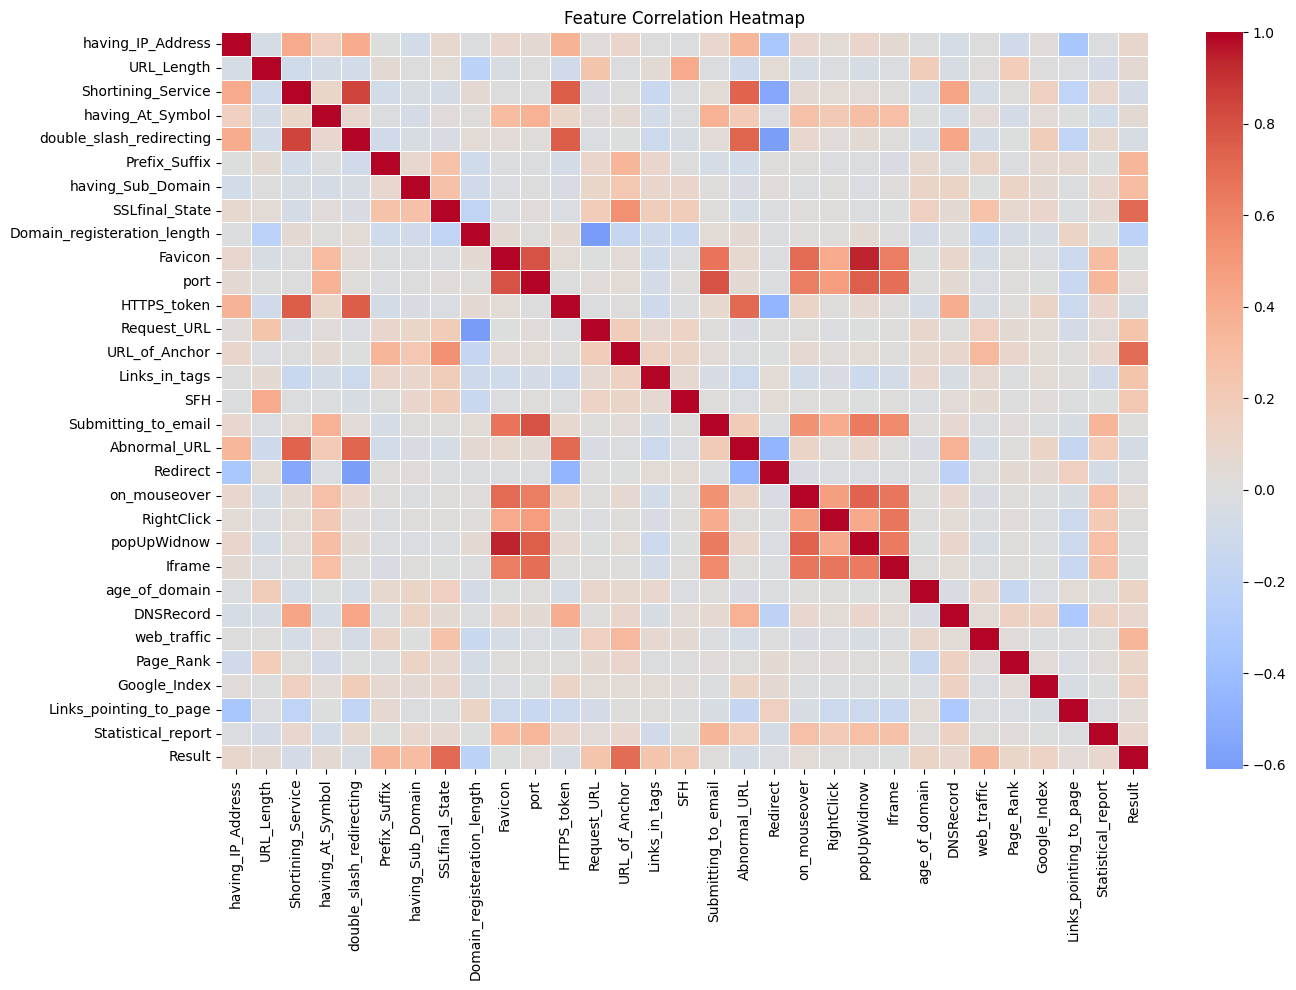

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DATASET INFO ===")
print(df.info())

print("\n=== CLASS DISTRIBUTION ===")
print(df['Result'].value_counts())

print("\n=== NULL VALUES ===")
print(df.isnull().sum().sum(), "null values found")

plt.figure(figsize=(6,4))
df['Result'].value_counts().plot(kind='bar',
                                  color=['#1D9E75','#D85A30'])
plt.title('Class Distribution: Phishing vs Legitimate')
plt.xlabel('Class (-1=Phishing, 1=Legitimate)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

**Preprocess**

X/y split, train/test split 80-20

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Result', axis=1)
y = df['Result']

y = y.map({-1: 0, 1: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Class balance in train:", y_train.value_counts().to_dict())

Training size: (8844, 30)
Testing size: (2211, 30)
Class balance in train: {1: 4926, 0: 3918}


**Train 6 Models**

LR, DT, RF, SVM, XGBoost, MLP

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42),
    'MLP Neural Network':  MLPClassifier(hidden_layer_sizes=(100,50),
                                          max_iter=500, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred)*100, 2),
        'Precision': round(precision_score(y_test, y_pred)*100, 2),
        'Recall':    round(recall_score(y_test, y_pred)*100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred)*100, 2)
    }
    trained_models[name] = model
    print(f"  Accuracy: {results[name]['Accuracy']}%")

print("\nAll models trained!")

Training Logistic Regression...
  Accuracy: 92.9%
Training Decision Tree...
  Accuracy: 97.11%
Training Random Forest...
  Accuracy: 97.42%
Training SVM...
  Accuracy: 94.89%
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:16:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 97.38%
Training MLP Neural Network...
  Accuracy: 96.79%

All models trained!


**Metrics Table**

accuracy, precision, recall, F1 all models

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)

print("="*60)
print("MODEL PERFORMANCE COMPARISON (in %)")
print("="*60)
print(results_df.to_string())
print("="*60)
print(f"\nBest Model: {results_df['Accuracy'].idxmax()}")
print(f"Best Accuracy: {results_df['Accuracy'].max()}%")

MODEL PERFORMANCE COMPARISON (in %)
                     Accuracy  Precision  Recall  F1 Score
Random Forest           97.42      96.96   98.46     97.70
XGBoost                 97.38      96.88   98.46     97.66
Decision Tree           97.11      97.02   97.81     97.41
MLP Neural Network      96.79      96.70   97.56     97.13
SVM                     94.89      94.02   96.99     95.48
Logistic Regression     92.90      92.42   95.04     93.71

Best Model: Random Forest
Best Accuracy: 97.42%


**All Graphs**

confusion matrix, ROC, features, bar chart



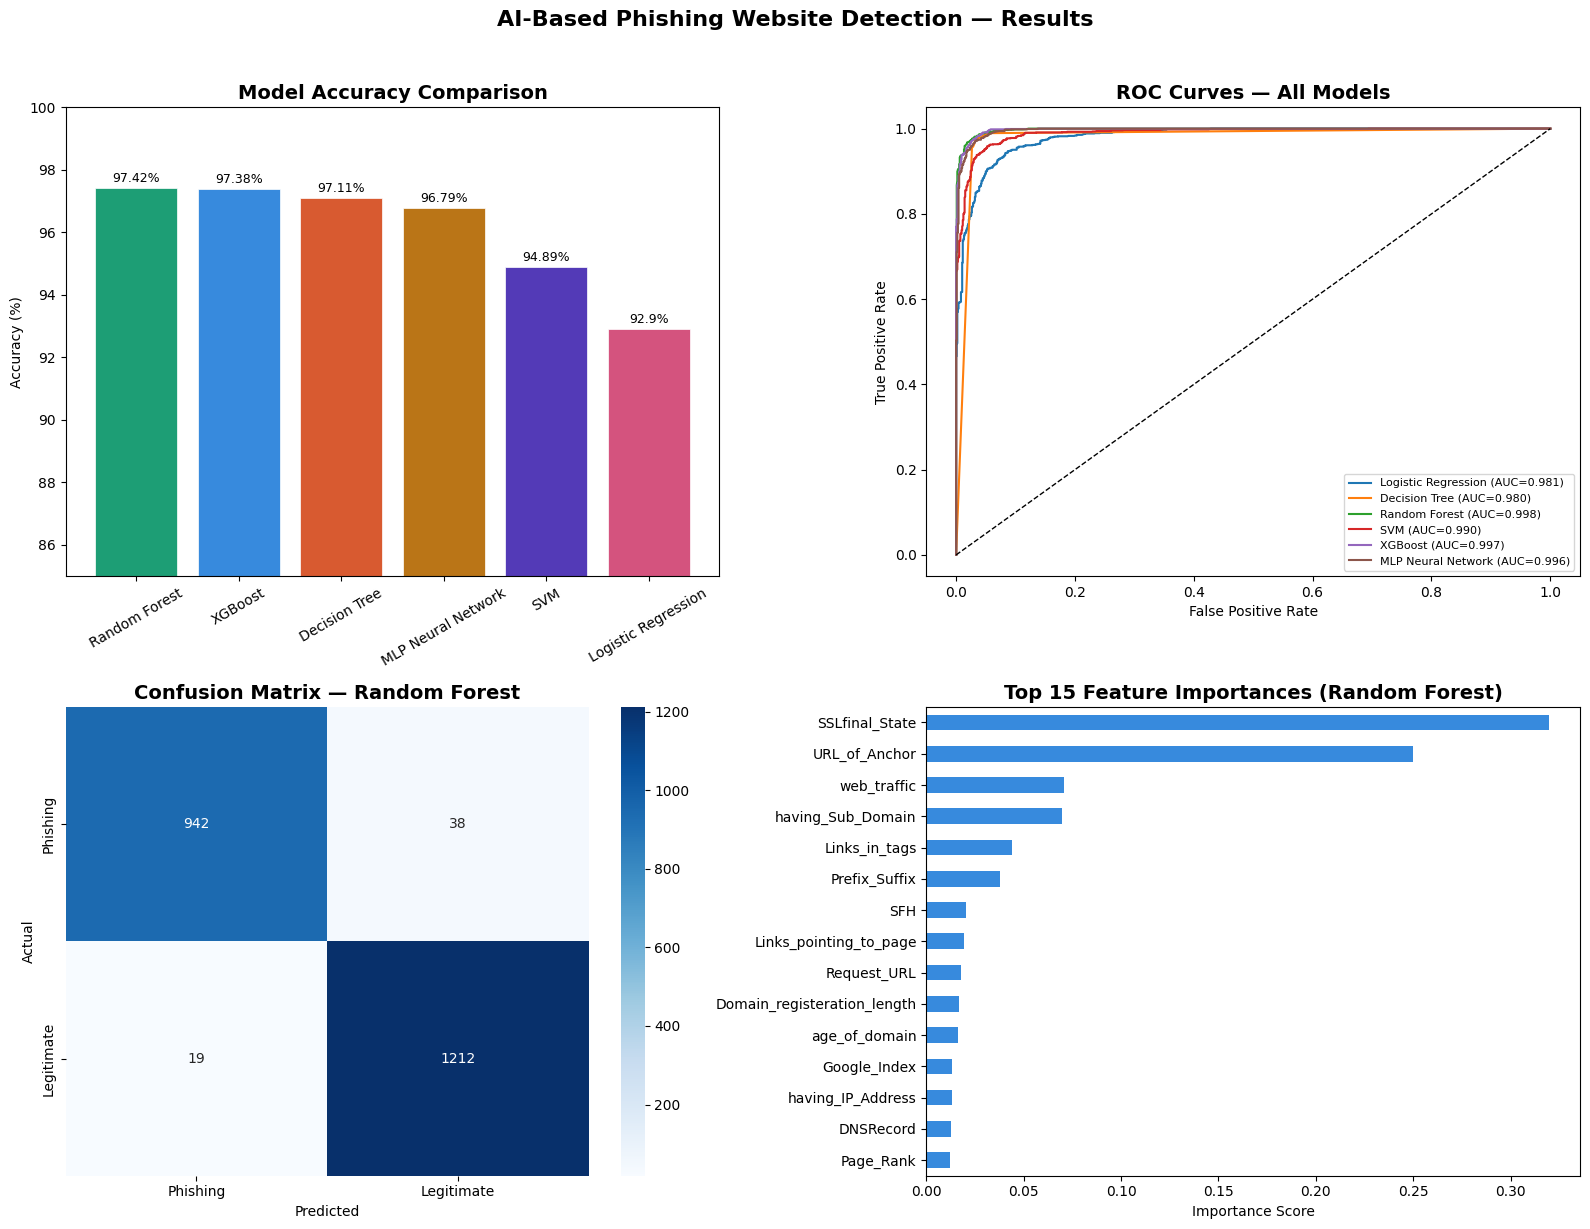

Graphs saved!


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graph 1 — Bar Chart Model Comparison
ax1 = axes[0, 0]
colors = ['#1D9E75','#378ADD','#D85A30','#BA7517','#533AB7','#D4537E']
bars = ax1.bar(results_df.index, results_df['Accuracy'],
               color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim([85, 100])
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val}%', ha='center', va='bottom', fontsize=9)

# Graph 2 — ROC Curve
ax2 = axes[0, 1]
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', linewidth=1.5)
ax2.plot([0,1],[0,1],'k--', linewidth=1)
ax2.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=8, loc='lower right')

# Graph 3 — Confusion Matrix (Best Model)
ax3 = axes[1, 0]
best_model_name = results_df['Accuracy'].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Phishing','Legitimate'],
            yticklabels=['Phishing','Legitimate'])
ax3.set_title(f'Confusion Matrix — {best_model_name}',
              fontsize=14, fontweight='bold')
ax3.set_ylabel('Actual')
ax3.set_xlabel('Predicted')

# Graph 4 — Feature Importance (Random Forest)
ax4 = axes[1, 1]
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_,
                         index=X.columns)
top_features = importances.nlargest(15)
top_features.sort_values().plot(kind='barh', ax=ax4,
                                 color='#378ADD')
ax4.set_title('Top 15 Feature Importances (Random Forest)',
              fontsize=14, fontweight='bold')
ax4.set_xlabel('Importance Score')

plt.suptitle('AI-Based Phishing Website Detection — Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_results_graphs.png', dpi=200, bbox_inches='tight')
plt.show()
print("Graphs saved!")

**SHAP Explainability**

why model made each decision

Generating SHAP explanation for XGBoost...


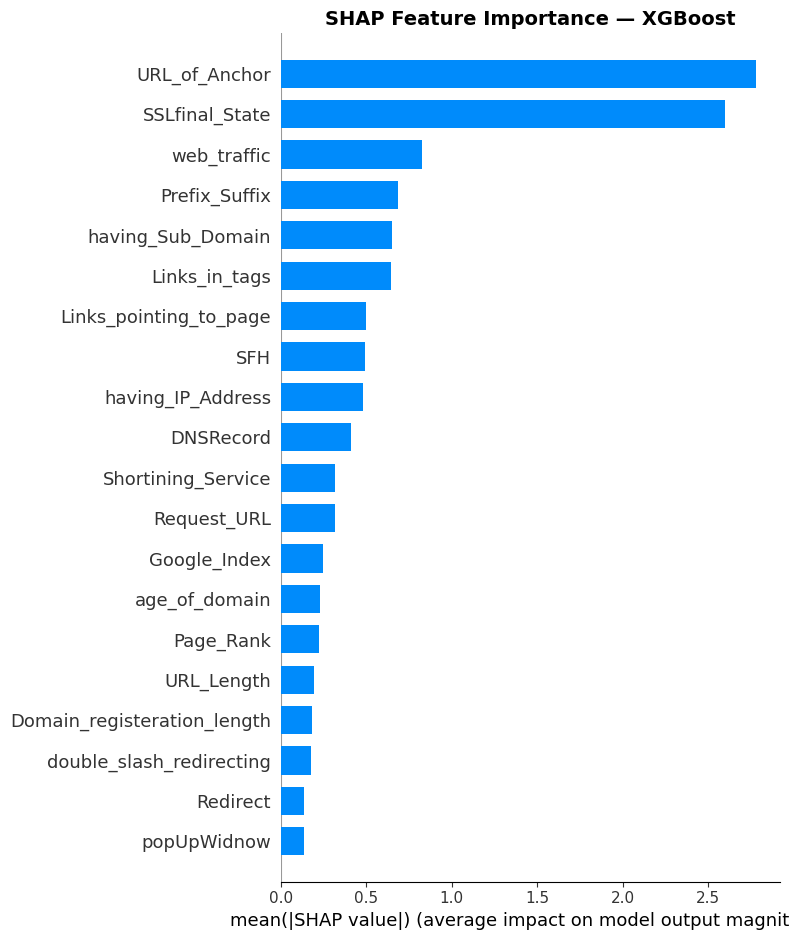

SHAP plot saved!


In [ ]:
import shap
import matplotlib.pyplot as plt

print("Generating SHAP explanation for XGBoost...")

xgb_model = trained_models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()
print("SHAP plot saved!")

**Save All Results**

In [ ]:
results_df.to_csv('model_results.csv')

print("FILES SAVED — Download these for your paper:")
print("1. all_results_graphs.png  → put in Results section")
print("2. shap_importance.png     → put in Discussion section")
print("3. correlation_heatmap.png → put in Methodology section")
print("4. class_distribution.png  → put in Dataset section")
print("5. model_results.csv       → make table in paper")

from google.colab import files
files.download('all_results_graphs.png')
files.download('shap_importance.png')
files.download('model_results.csv')

FILES SAVED — Download these for your paper:
1. all_results_graphs.png  → put in Results section
2. shap_importance.png     → put in Discussion section
3. correlation_heatmap.png → put in Methodology section
4. class_distribution.png  → put in Dataset section
5. model_results.csv       → make table in paper


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import cross_val_score

print("=== 5-FOLD CROSS VALIDATION ===")
for name, model in trained_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

=== 5-FOLD CROSS VALIDATION ===
Logistic Regression: 92.28% (+/- 0.48%)
Decision Tree: 95.22% (+/- 3.04%)
Random Forest: 96.84% (+/- 1.51%)
SVM: 94.46% (+/- 0.66%)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost: 96.65% (+/- 1.40%)
MLP Neural Network: 96.10% (+/- 1.65%)
